In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

In [14]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

In [15]:
observed_entries_file = '../results/results_data/observed_entries_syn_10000_1000_r10_p1e-01.pt'
privacy_tradeoff_file = '../results/results_data/privacy_tradeoff_syn_10000_1000_r10_p1e-02.pt'
users_file = '../results/results_data/users_syn_1000_1000_r10_p1e-02.pt'
ob2_file = '../results/results_data/ob2_10_syn_1000_1000_r10_p1e-01.pt'

results = torch.load(ob2_file)

[1000, 5000, 10000, 20000, 30000]


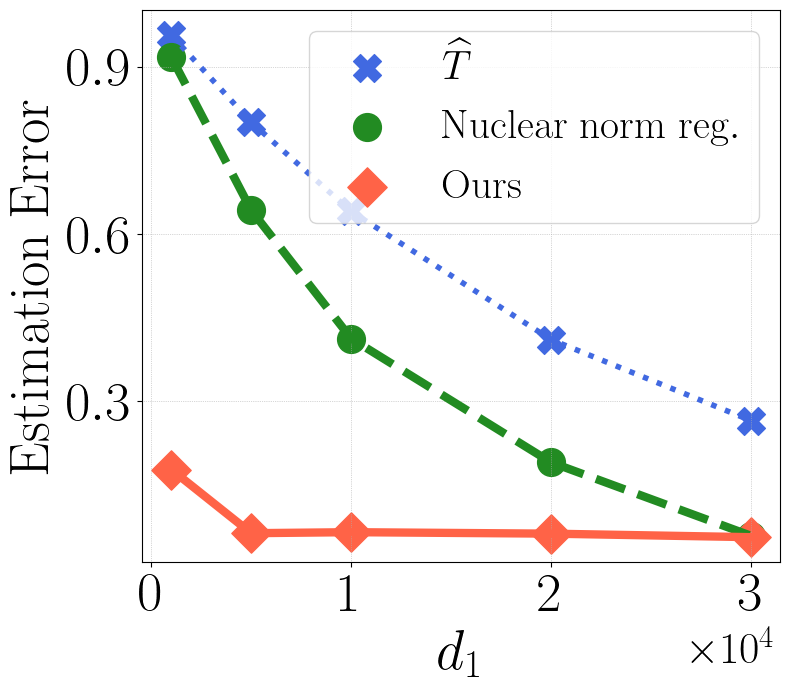

In [16]:
# observed entries
# title = r'$\mathrm{Synthetic~(2~obervations)}$'
X = results['user_list']
#xticks = [10000,  30000, 50000, 70000]
print(X)


original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
T_freq_rmse_mean = results['T_freq_rmse_mean']
T_freq_rmse_std = results['T_freq_rmse_std']
SVD_T_err_mean = results['SVD_T_err_mean']
SVD_T_err_std = results['SVD_T_err_std']

X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']

ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']

err_mean = results['err_mean']
err_std = results['err_std']
rmse_mean = results['rmse_mean']
rmse_std = results['rmse_std'] 

f, ax = plt.subplots(figsize=(8,7))

enhance = ob2_rmse_mean / rmse_mean
enhance = rmse_mean / ob2_rmse_mean

plt.plot(X, T_freq_err_mean, lw=4, color='royalblue',ls="dotted" )
plt.plot(X, ob2_err_mean, lw=6, color='forestgreen', ls="dashed")
plt.plot(X, err_mean, color='tomato',lw=6)

plt.scatter(X, T_freq_err_mean, s=400, color='royalblue', label=r"$\widehat{T}$", marker="X")
plt.scatter(X, ob2_err_mean, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(X, err_mean, s=400, color='tomato', label=r"$\mathrm{Ours}$", marker="D")

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{Estimation~Error}$", fontsize=40)

plt.yticks([0.3, 0.6, 0.9],fontsize=40)
xticks = [0, 10000, 20000, 30000]
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
ax.xaxis.get_offset_text().set_fontsize(32)
plt.legend(fontsize=30, loc='upper right')

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"ten_entries_per_row_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

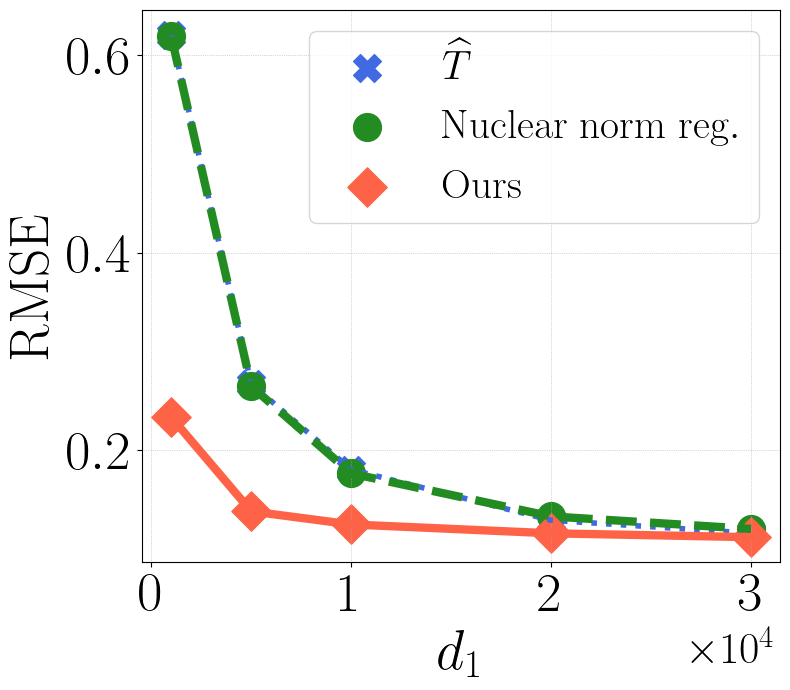

In [17]:
# observed entries
X = results['user_list']

original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']

X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']

ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']

err_mean = results['err_mean']
err_std = results['err_std']
rmse_mean = results['rmse_mean']
rmse_std = results['rmse_std'] 
f, ax = plt.subplots(figsize=(8,7))

plt.plot(X, T_freq_rmse_mean, lw=4, color='royalblue',ls="dotted" )
plt.plot(X, ob2_rmse_mean, lw=6, color='forestgreen', ls="dashed")
plt.plot(X, rmse_mean, color='tomato',lw=6)

plt.scatter(X, T_freq_rmse_mean, s=400, color='royalblue', label=r"$\widehat{T}$", marker="X")
plt.scatter(X, ob2_rmse_mean, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(X, rmse_mean, s=400, color='tomato', label=r"$\mathrm{Ours}$", marker="D")

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

plt.xticks([0, 10000, 20000, 30000], fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
ax.xaxis.get_offset_text().set_fontsize(32)
plt.legend(fontsize = 30, loc='upper right')

plt.yticks([0.2, 0.4, 0.6], fontsize=40)

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"ten_entries_per_row_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()